# Motif Enrichment Plots for ASC Metatypes

This notebook summarizes chromVAR motif enrichment results across ASC metatypes and generates publication-style figures.

Workflow:
1. Load helper functions and input tables.
2. Filter motifs to those with matched TF expression.
3. Plot motif counts and top enriched motifs by model estimate.
4. Overlay chromVAR z-score summaries for the same motifs.

In [ ]:
library(MOCHA)
library(SummarizedExperiment)
library(dplyr)
library(ggplot2)
library(viridis)
library(matrixStats)

helper_candidates <- c("../helper_functions.r", "helper_functions.r")
helper_path <- helper_candidates[file.exists(helper_candidates)][1]
if (is.na(helper_path)) {
  stop("Could not find helper_functions.r. Open the notebook from the repo root or figures directory.")
}
source(helper_path)


Attaching package: ‘MOCHA’


The following objects are masked from ‘package:ChAI’:

    bulkDimReduction, bulkUMAP, getModelValues, renameCellTypes


Warning message:
“package ‘SummarizedExperiment’ was built under R version 4.4.2”
Loading required package: MatrixGenerics

Loading required package: matrixStats

Warning message:
“package ‘matrixStats’ was built under R version 4.4.3”

Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgs

## Load Inputs

Set run/output paths and load the chromVAR ANOVA results together with the annotated pseudobulk RNA object used for TF expression filtering.

In [ ]:
run_dir_candidates <- c("../Run_Metatype_threshold", "Run_Metatype_threshold")
run_dir <- run_dir_candidates[file.exists(run_dir_candidates)][1]
if (is.na(run_dir)) {
  stop("Could not find Run_Metatype_threshold. Open the notebook from the repo root or figures directory.")
}

output_dir <- "."
anova_csv <- file.path(run_dir, "Meta_EnrichedMotifs_ChromVAR_ANOVA.csv")
rna_rds <- file.path(run_dir, "ChAI_PseudobulkRNA_Meta_Annotated.rds")
chrom_rds <- file.path(run_dir, "ChAI_ChromVAR_scores_Meta.rds")

In [ ]:
anovaEnrichments <- read.csv(anova_csv)
rnaSE <- readRDS(rna_rds)

exprGenes <- thresholdGenes(
  rnaSE,
  cellPopulation = "all",
  detectionThreshold = 0.001,
  expressionThreshold = 2,
  cellCountThreshold = 20
)
lengths(exprGenes)

## Prepare Motif Tables

Add metatype labels, compute a signed significance score, and retain motifs whose TF is expressed in the matched metatype.

In [ ]:
is_motif_expressed <- function(motif_name, cell_type_name, expr_genes) {
  if (!(cell_type_name %in% names(expr_genes))) {
    return(FALSE)
  }
  motif_name %in% expr_genes[[cell_type_name]]
}

anovaEnrichments <- anovaEnrichments %>%
  mutate(
    cell_type = sub(" effect$", "", contrast),
    mlogadjpval = -log10(pmax(p_adj, .Machine$double.xmin)),
    statistic = mlogadjpval * estimate
  )

expressedEnrichments <- anovaEnrichments
for (ct in names(exprGenes)) {
  expressedEnrichments <- dplyr::filter(
    expressedEnrichments,
    (motif %in% exprGenes[[ct]] & cell_type == ct) | cell_type != ct
  )
}

anovaEnrichments <- anovaEnrichments %>%
  rowwise() %>%
  mutate(is_expressed = is_motif_expressed(motif, cell_type, exprGenes)) %>%
  ungroup()

write.csv(anovaEnrichments, file.path(output_dir, "anovaEnrichments.csv"), row.names = FALSE)

## Count Enriched Motifs

Summarize the number of significantly enriched, expression-supported motifs per metatype and export a bar plot.

In [ ]:
sig_up_motifs <- expressedEnrichments %>%
  filter(p_adj < 0.1, estimate > 0)

summary_counts <- as.data.frame(table(sig_up_motifs$cell_type))
colnames(summary_counts) <- c("cluster", "value")

metas <- paste0("ASC", 1:5)
meta_palette <- c("#1C7987", "#7286AC", "#7A3859", "#99C2A2", "#F0A7A0")
names(meta_palette) <- metas

ggplot(summary_counts, aes(cluster, value, fill = cluster)) +
  geom_col() +
  theme_linedraw() +
  scale_fill_manual(values = meta_palette) +
  labs(x = NULL, y = "# of Enriched Motifs") +
  theme(
    legend.position = "none",
    panel.grid.major.x = element_blank(),
    axis.text.x = element_text(hjust = 1, angle = 45)
  )

ggsave(file.path(output_dir, "bars_motifs_meta.png"), width = 2.6, height = 3)

## Top Motif Bubble Plot

Select the top 20 positively enriched motifs per metatype and plot model estimates as a bubble plot.

In [ ]:
top20 <- expressedEnrichments %>%
  filter(p_adj < 0.1, estimate > 0) %>%
  group_by(cell_type) %>%
  slice_max(order_by = estimate, n = 20, with_ties = FALSE) %>%
  ungroup()

selected_TFs <- unique(top20$motif)

filtered_motifs <- anovaEnrichments %>%
  left_join(
    top20 %>%
      select(cell_type, motif) %>%
      mutate(is_top20 = TRUE),
    by = c("cell_type", "motif")
  ) %>%
  mutate(is_top20 = coalesce(is_top20, FALSE)) %>%
  filter(motif %in% selected_TFs) %>%
  mutate(motif = factor(motif, levels = selected_TFs))

inf <- viridis(256, option = "inferno")

In [ ]:
ggplot(
  filtered_motifs,
  aes(
    cell_type,
    motif,
    fill = estimate,
    size = mlogadjpval,
    color = p_adj < 0.1 & estimate > 0
  )
) +
  geom_point(shape = 21, stroke = 1.2) +
  theme_bw() +
  scale_fill_gradientn(
    colours = c(inf[40], "white", inf[220]),
    values = scales::rescale(c(min(filtered_motifs$estimate), 0, max(filtered_motifs$estimate)))
  ) +
  scale_color_manual(values = c("white", "grey50")) +
  scale_size_area(max_size = 5) +
  scale_x_discrete(limits = function(x) rev(x)) +
  theme(
    panel.grid = element_blank(),
    axis.text.x = element_text(hjust = 1, angle = 45),
    legend.position = "bottom",
    legend.box = "horizontal",
    legend.key.width = grid::unit(1, "cm"),
    legend.key.height = grid::unit(1, "cm"),
    legend.text.align = 0.5
  ) +
  labs(
    x = NULL,
    y = NULL,
    size = "-log10 adjusted p-value",
    color = "Significant and positive",
    fill = "Estimate"
  ) +
  guides(
    size = guide_legend(
      title.position = "top",
      label.position = "top",
      override.aes = list(shape = 21, fill = "grey50", color = "grey50", stroke = 0)
    ),
    color = guide_legend(title.position = "top", label.position = "top")
  ) +
  coord_flip()

ggsave(file.path(output_dir, "bubble_motif_enrichment_estimate_no_top20.png"), width = 12, height = 3)

       
        ASC1 ASC2 ASC3 ASC4 ASC5
  FALSE  757  453  378  377  431
  TRUE   113  417  492  493  439

## chromVAR z-Score Overlay

Load the chromVAR score object, summarize motif activity per metatype, and overlay those values on the same motif panel.

In [ ]:
chrom <- readRDS(chrom_rds)
z_scores <- chrom$Z_Score

means_list <- lapply(assayNames(z_scores), function(ct) {
  medians <- matrixStats::rowMedians(assays(z_scores)[[ct]], na.rm = TRUE)
  data.frame(
    motif = names(medians),
    median_zscore = medians,
    cell_type = ct,
    row.names = NULL
  )
})

means_df <- bind_rows(means_list)
summary(means_df$median_zscore)

In [ ]:
merged_df <- merge(filtered_motifs, means_df, by = c("motif", "cell_type"), all.x = TRUE)
merged_df_full <- merge(anovaEnrichments, means_df, by = c("motif", "cell_type"), all.x = TRUE)

write.csv(merged_df_full, file.path(output_dir, "anovaEnrichments_zscore.csv"), row.names = FALSE)
summary(merged_df$median_zscore)

cluster,value
<fct>,<int>
ASC1,26
ASC2,85
ASC3,224
ASC4,244
ASC5,203


In [ ]:
ggplot(
  merged_df,
  aes(
    cell_type,
    motif,
    fill = median_zscore,
    size = mlogadjpval,
    color = p_adj < 0.1 & estimate > 0
  )
) +
  geom_point(shape = 21, stroke = 1.2) +
  theme_bw() +
  scale_fill_gradientn(
    colours = c(inf[40], "white", inf[220]),
    values = scales::rescale(c(min(merged_df$median_zscore, na.rm = TRUE), 0, max(merged_df$median_zscore, na.rm = TRUE)))
  ) +
  scale_color_manual(values = c("white", "grey50")) +
  scale_size_area(max_size = 5) +
  scale_x_discrete(limits = function(x) rev(x)) +
  theme(
    panel.grid = element_blank(),
    axis.text.x = element_text(hjust = 1, angle = 45),
    legend.position = "bottom",
    legend.box = "horizontal",
    legend.key.width = grid::unit(1, "cm"),
    legend.key.height = grid::unit(1, "cm"),
    legend.text.align = 0.5
  ) +
  labs(
    x = NULL,
    y = NULL,
    size = "-log10 adjusted p-value",
    color = "Significant and positive",
    fill = "Median z-score"
  ) +
  guides(
    size = guide_legend(
      title.position = "top",
      label.position = "top",
      override.aes = list(shape = 21, fill = "grey50", color = "grey50", stroke = 0)
    ),
    color = guide_legend(title.position = "top", label.position = "top")
  ) +
  coord_flip()

ggsave(file.path(output_dir, "bubble_motif_enrichment_zscore_no_top20.png"), width = 12, height = 3)

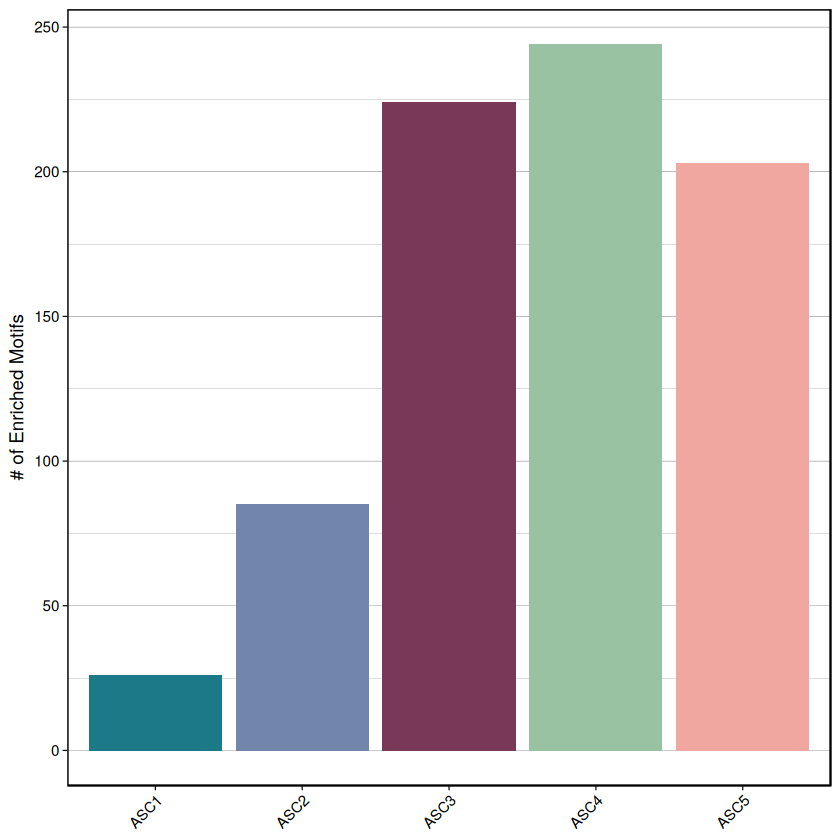

In [ ]:
scaled_df <- merged_df %>%
  group_by(motif) %>%
  mutate(median_zscore_scaled = as.numeric(scale(median_zscore))) %>%
  ungroup()

ggplot(
  scaled_df,
  aes(
    cell_type,
    motif,
    fill = median_zscore_scaled,
    size = mlogadjpval,
    color = p_adj < 0.1 & estimate > 0
  )
) +
  geom_point(shape = 21, stroke = 1.2) +
  theme_bw() +
  scale_fill_gradientn(
    colours = c(inf[40], "white", inf[220]),
    values = scales::rescale(c(min(scaled_df$median_zscore_scaled, na.rm = TRUE), 0, max(scaled_df$median_zscore_scaled, na.rm = TRUE)))
  ) +
  scale_color_manual(values = c("white", "grey50")) +
  scale_size_area(max_size = 5) +
  scale_x_discrete(limits = function(x) rev(x)) +
  theme(
    panel.grid = element_blank(),
    axis.text.x = element_text(hjust = 1, angle = 45),
    legend.position = "bottom",
    legend.box = "horizontal",
    legend.key.width = grid::unit(1, "cm"),
    legend.key.height = grid::unit(1, "cm"),
    legend.text.align = 0.5
  ) +
  labs(
    x = NULL,
    y = NULL,
    size = "-log10 adjusted p-value",
    color = "Significant and positive",
    fill = "Scaled median z-score"
  ) +
  guides(
    size = guide_legend(
      title.position = "top",
      label.position = "top",
      override.aes = list(shape = 21, fill = "grey50", color = "grey50", stroke = 0)
    ),
    color = guide_legend(title.position = "top", label.position = "top")
  ) +
  coord_flip()

ggsave(file.path(output_dir, "bubble_motif_enrichment_zscore_scaled.png"), width = 12, height = 3)